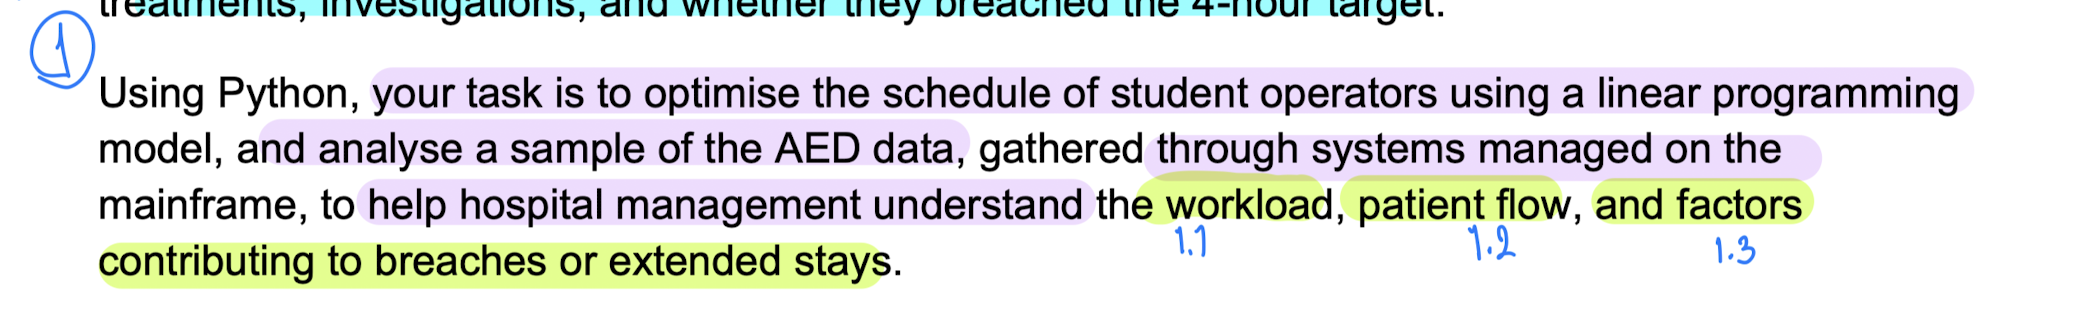

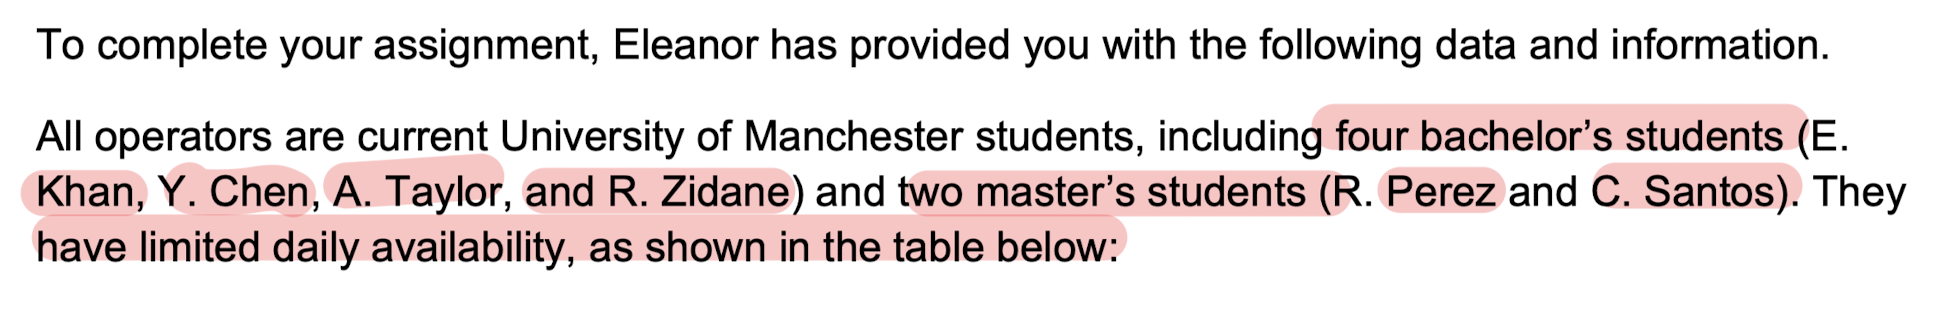

In [8]:
pip install pulp

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pulp

In [10]:
model = pulp.LpProblem(name= 'Hos_Management', sense = pulp.LpMinimize)

In [11]:
model = pulp.LpProblem(name= 'Hos_Management', sense = pulp.LpMinimize)
# --- Sets ---
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
ops  = ["EK", "YC", "AT", "RZ", "RP", "CS"]
x = pulp.LpVariable.dicts("hours", (ops, days), lowBound=0, cat="Continuous")

In [12]:
model = pulp.LpProblem(name= 'Hos_Management', sense = pulp.LpMinimize)
# --- Sets ---
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
ops  = ["EK", "YC", "AT", "RZ", "RP", "CS"]
x = pulp.LpVariable.dicts("hours", (ops, days), lowBound=0, cat="Continuous")
# --- Data (from brief) ---
wage = {"EK":25, "YC":26, "AT":24, "RZ":23, "RP":28, "CS":30}  # £/hour [file:1]
min_week = {"EK":8, "YC":8, "AT":8, "RZ":8, "RP":7, "CS":7}   # hours/week [file:1]

avail = {
    ("EK","Mon"):6, ("EK","Tue"):0, ("EK","Wed"):6, ("EK","Thu"):0, ("EK","Fri"):6,
    ("YC","Mon"):0, ("YC","Tue"):6, ("YC","Wed"):0, ("YC","Thu"):6, ("YC","Fri"):0,
    ("AT","Mon"):4, ("AT","Tue"):8, ("AT","Wed"):4, ("AT","Thu"):0, ("AT","Fri"):4,
    ("RZ","Mon"):5, ("RZ","Tue"):5, ("RZ","Wed"):5, ("RZ","Thu"):0, ("RZ","Fri"):5,
    ("RP","Mon"):3, ("RP","Tue"):0, ("RP","Wed"):3, ("RP","Thu"):8, ("RP","Fri"):0,
    ("CS","Mon"):0, ("CS","Tue"):0, ("CS","Wed"):0, ("CS","Thu"):6, ("CS","Fri"):2
}
model += pulp.lpSum(wage[o] * x[o][d] for o in ops for d in days)

# 1) Availability constraints
for o in ops:
    for d in days:
        model += x[o][d] <= avail[(o, d)], f"avail_{o}_{d}"  # cannot exceed availability

# 2) Daily coverage: 14 hours each weekday (8am–10pm)
for d in days:
    model += pulp.lpSum(x[o][d] for o in ops) == 14, f"coverage_{d}"  # 14 hours/day

# 3) Weekly minimum commitments
for o in ops:
    model += pulp.lpSum(x[o][d] for d in days) >= min_week[o], f"minweek_{o}"  # min weekly hours

In [13]:
# Solve
model.solve(pulp.PULP_CBC_CMD(msg=True))
print("Status:", pulp.LpStatus[model.status], "Cost:", pulp.value(model.objective))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/spearxz/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/a0d21cdc61204ae596b18b7a9d587c1f-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/a0d21cdc61204ae596b18b7a9d587c1f-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 46 COLUMNS
At line 167 RHS
At line 209 BOUNDS
At line 210 ENDATA
Problem MODEL has 41 rows, 30 columns and 90 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 11 (-30) rows, 18 (-12) columns and 36 (-54) elements
0  Obj 669.79995 Primal inf 64.599993 (11)
11  Obj 1755
Optimal - objective value 1755
After Postsolve, objective 1755, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 1755 - 11 iterations time 0.002, Presolve 0.00
Option for 

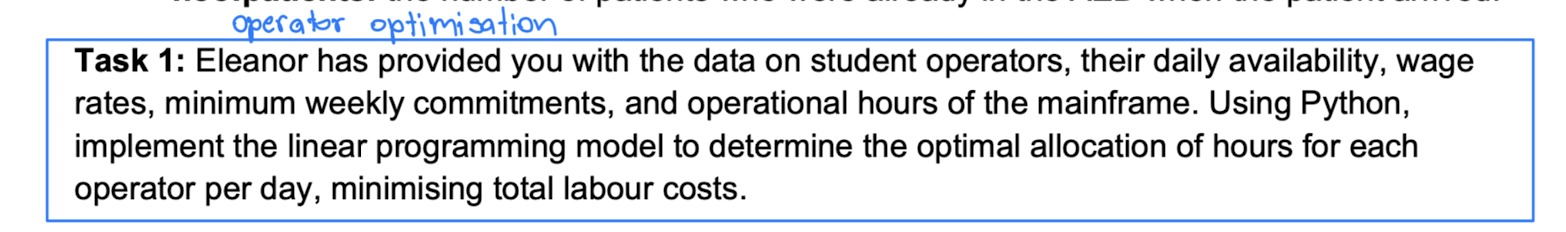

In [14]:
import pandas as pd

schedule = pd.DataFrame(
    {d: [x[o][d].value() for o in ops] for d in days},
    index=ops
)
schedule["WeeklyTotal"] = schedule.sum(axis=1)
print(schedule)


    Mon  Tue  Wed  Thu  Fri  WeeklyTotal
EK  2.0  0.0  4.0  0.0  3.0          9.0
YC  0.0  2.0  0.0  6.0  0.0          8.0
AT  4.0  7.0  4.0  0.0  4.0         19.0
RZ  5.0  5.0  5.0  0.0  5.0         20.0
RP  3.0  0.0  1.0  3.0  0.0          7.0
CS  0.0  0.0  0.0  5.0  2.0          7.0


In [15]:
for v in model.variables():
    print(v.name, "=", v.varValue, "Reduced Cost =", v.dj)
for name, c in model.constraints.items():
    print(name, "shadow price =", c.pi, "slack =", c.slack)

hours_AT_Fri = 4.0 Reduced Cost = 0.0
hours_AT_Mon = 4.0 Reduced Cost = 0.0
hours_AT_Thu = 0.0 Reduced Cost = 0.0
hours_AT_Tue = 7.0 Reduced Cost = 0.0
hours_AT_Wed = 4.0 Reduced Cost = 0.0
hours_CS_Fri = 2.0 Reduced Cost = 0.0
hours_CS_Mon = 0.0 Reduced Cost = 0.0
hours_CS_Thu = 5.0 Reduced Cost = 0.0
hours_CS_Tue = 0.0 Reduced Cost = 1.0
hours_CS_Wed = 0.0 Reduced Cost = 0.0
hours_EK_Fri = 3.0 Reduced Cost = 0.0
hours_EK_Mon = 2.0 Reduced Cost = 0.0
hours_EK_Thu = 0.0 Reduced Cost = 0.0
hours_EK_Tue = 0.0 Reduced Cost = 1.0
hours_EK_Wed = 4.0 Reduced Cost = 0.0
hours_RP_Fri = 0.0 Reduced Cost = 0.0
hours_RP_Mon = 3.0 Reduced Cost = 0.0
hours_RP_Thu = 3.0 Reduced Cost = 0.0
hours_RP_Tue = 0.0 Reduced Cost = 1.0
hours_RP_Wed = 1.0 Reduced Cost = 0.0
hours_RZ_Fri = 5.0 Reduced Cost = 0.0
hours_RZ_Mon = 5.0 Reduced Cost = 0.0
hours_RZ_Thu = 0.0 Reduced Cost = 0.0
hours_RZ_Tue = 5.0 Reduced Cost = 0.0
hours_RZ_Wed = 5.0 Reduced Cost = 0.0
hours_YC_Fri = 0.0 Reduced Cost = 0.0
hours_YC_Mon

Reduced cost → variables
- if a variable is 0 and “not worth using,” it can show a non‑zero reduced cost (meaning its objective coefficient would need to improve by at least that amount before it becomes attractive)  

Shadow price & slack → constraints  
- Slack is simply “unused room” in a constraint: for a ≤ constraint, it’s typically RHS − LHS at the solution, so slack > 0 means the constraint is not tight.  
- Shadow price (also called dual price) is the change in the optimal objective value per +1 unit increase in the constraint RHS, and it mainly matters when a constraint is biinding (tight).
- If a constraint has slack, it often has shadow price 0, because getting more of that already-unused resource won’t improve the objective.

How this matches your scheduling output  
- Your coverage_Mon == 14 type constraints are binding by design, so slack is ~0 and you often see a meaningful shadow price there (it’s the implied marginal cost of needing 1 extra hour of coverage that day).
- Many avail_* constraints have positive slack (not using all availability), so their shadow price is often 0; but when an availability constraint is tight (slack ~0), it can have a nonzero shadow price because extra availability would let the model swap in cheaper hours.




# gurobipy: faster solves for the fairness/skills scenarios

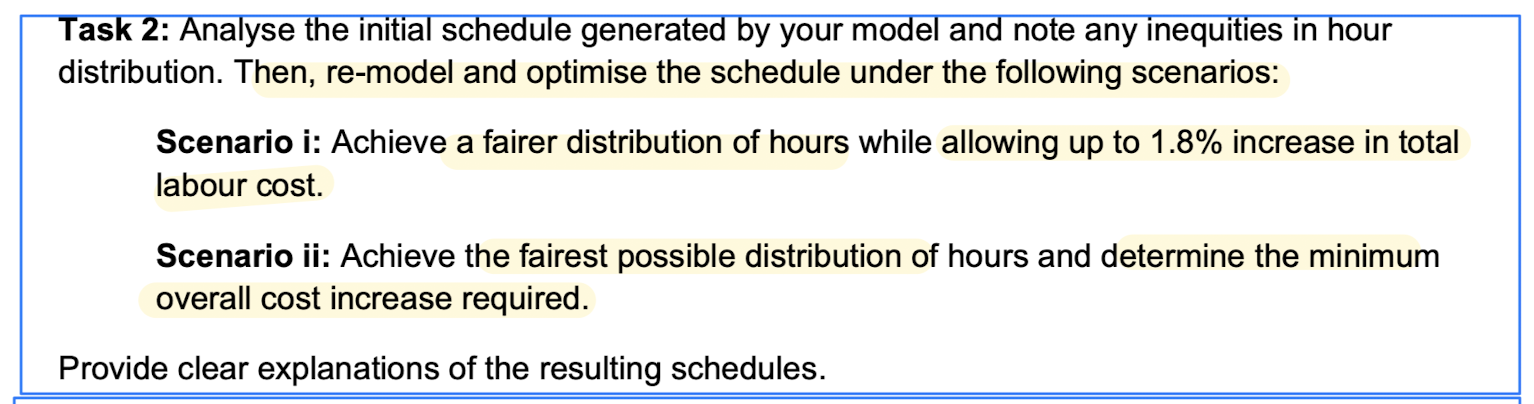

### 2.1 Scenario (i): Fairer with ≤ 1.8% cost increase  
Objective = minimise unfairness (max weekly hours − min weekly hours)  
Constraint = cost ≤ 1.018 × base_cost

In [28]:
def build_task1_model():
    m = pulp.LpProblem(name='Hos_Management_T1', sense=pulp.LpMinimize)

    days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
    ops  = ["EK", "YC", "AT", "RZ", "RP", "CS"]

    x = pulp.LpVariable.dicts("hours", (ops, days), lowBound=0)

    wage = {"EK":25, "YC":26, "AT":24, "RZ":23, "RP":28, "CS":30}
    min_week = {"EK":8, "YC":8, "AT":8, "RZ":8, "RP":7, "CS":7}

    avail = {
        ("EK","Mon"):6, ("EK","Tue"):0, ("EK","Wed"):6, ("EK","Thu"):0, ("EK","Fri"):6,
        ("YC","Mon"):0, ("YC","Tue"):6, ("YC","Wed"):0, ("YC","Thu"):6, ("YC","Fri"):0,
        ("AT","Mon"):4, ("AT","Tue"):8, ("AT","Wed"):4, ("AT","Thu"):0, ("AT","Fri"):4,
        ("RZ","Mon"):5, ("RZ","Tue"):5, ("RZ","Wed"):5, ("RZ","Thu"):0, ("RZ","Fri"):5,
        ("RP","Mon"):3, ("RP","Tue"):0, ("RP","Wed"):3, ("RP","Thu"):8, ("RP","Fri"):0,
        ("CS","Mon"):0, ("CS","Tue"):0, ("CS","Wed"):0, ("CS","Thu"):6, ("CS","Fri"):2
    }

    # Objective: cost
    m += pulp.lpSum(wage[o] * x[o][d] for o in ops for d in days)

    # Availability
    for o in ops:
        for d in days:
            m += x[o][d] <= avail[(o, d)], f"avail_{o}_{d}"

    # Daily coverage
    for d in days:
        m += pulp.lpSum(x[o][d] for o in ops) == 14, f"coverage_{d}"

    # Weekly minimums
    for o in ops:
        m += pulp.lpSum(x[o][d] for d in days) >= min_week[o], f"minweek_{o}"

    return m, x, ops, days, wage, min_week


In [29]:
m1, x1, ops, days, wage, min_week = build_task1_model()
m1.solve(pulp.PULP_CBC_CMD())
base_cost = pulp.value(m1.objective)
print("Task 1 cost:", base_cost)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/spearxz/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/646edf6687954cafb2fced63c332f342-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/646edf6687954cafb2fced63c332f342-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 46 COLUMNS
At line 167 RHS
At line 209 BOUNDS
At line 210 ENDATA
Problem MODEL has 41 rows, 30 columns and 90 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 11 (-30) rows, 18 (-12) columns and 36 (-54) elements
0  Obj 669.79995 Primal inf 64.599993 (11)
11  Obj 1755
Optimal - objective value 1755
After Postsolve, objective 1755, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 1755 - 11 iterations time 0.002, Presolve 0.00
Option for 

In [30]:
def build_task2_scenario1(base_cost):
    m, x, ops, days, wage, min_week = build_task1_model()

    # Weekly hours per operator
    weekly_hours = {o: pulp.lpSum(x[o][d] for d in days) for o in ops}

    # Fairness variables
    max_hours = pulp.LpVariable("max_hours", lowBound=0)
    min_hours = pulp.LpVariable("min_hours", lowBound=0)

    # Link weekly hours to max/min
    for o in ops:
        m += weekly_hours[o] <= max_hours
        m += weekly_hours[o] >= min_hours

    # Cost cap: ≤ 1.8% increase
    cost_expr = pulp.lpSum(wage[o] * x[o][d] for o in ops for d in days)
    m += cost_expr <= 1.018 * base_cost, "cost_cap_1p8"

    # NEW objective: minimise unfairness (gap)
    m.sense = pulp.LpMinimize
    m.setObjective(max_hours - min_hours)

    return m, x, weekly_hours, max_hours, min_hours

m2a, x2a, weekly_hours2a, max_h2a, min_h2a = build_task2_scenario1(base_cost)
m2a.solve(pulp.PULP_CBC_CMD(msg=False))

print("Scenario (i) fairness gap:", pulp.value(max_h2a - min_h2a))
print("Scenario (i) cost:", pulp.value(pulp.lpSum(wage[o] * x2a[o][d] for o in ops for d in days)
))


Scenario (i) fairness gap: 6.0
Scenario (i) cost: 1784.0


In [31]:
m2a, x2a, weekly_hours2a, max_h2a, min_h2a = build_task2_scenario1(base_cost)
m2a.solve(pulp.PULP_CBC_CMD(msg=True))

print("Scenario (i) fairness gap:", pulp.value(max_h2a - min_h2a))
print("Scenario (i) cost:", pulp.value(
    pulp.lpSum(wage[o] * x2a[o][d].value() for o in ops for d in days)
))


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/spearxz/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/f18edc1bb6264f428731cee3ac6181bc-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/f18edc1bb6264f428731cee3ac6181bc-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 59 COLUMNS
At line 254 RHS
At line 309 BOUNDS
At line 310 ENDATA
Problem MODEL has 54 rows, 32 columns and 192 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (-30) rows, 20 (-12) columns and 102 (-90) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 9.64205e-05 ( 0.00964205%) - largest zero change 9.3128486e-05
0  Obj 6.9025803 Primal inf 64.599993 (11) Dual inf 0.99990258 (1)
11  Obj 6.0071855
Optimal - objective value 6
Af

In [32]:
schedule2a = pd.DataFrame(
    {d: [x2a[o][d].value() for o in ops] for d in days},
    index=ops
)
schedule2a["WeeklyTotal"] = schedule2a.sum(axis=1)
print(schedule2a)


    Mon  Tue  Wed  Thu  Fri  WeeklyTotal
EK  6.0  0.0  2.0  0.0  6.0         14.0
YC  0.0  6.0  0.0  6.0  0.0         12.0
AT  4.0  3.0  4.0  0.0  3.0         14.0
RZ  1.0  5.0  5.0  0.0  3.0         14.0
RP  3.0  0.0  3.0  2.0  0.0          8.0
CS  0.0  0.0  0.0  6.0  2.0          8.0


In [33]:
def build_task2_abs_deviation(base_cost):
    import pulp

    # --- Reuse Task 1 ---
    m, x, ops, days, wage, min_week = build_task1_model()

    # --- Constants ---
    total_hours = 14 * len(days)          # 70
    mean_hours = total_hours / len(ops)   # 70 / 6 ≈ 11.667

    # --- Weekly hours per operator ---
    weekly_hours = {
        o: pulp.lpSum(x[o][d] for d in days) for o in ops
    }

    # --- Absolute deviation variables ---
    z = pulp.LpVariable.dicts(
        "abs_dev", ops, lowBound=0
    )

    # --- Absolute value constraints ---
    for o in ops:
        m += z[o] >= weekly_hours[o] - mean_hours
        m += z[o] >= mean_hours - weekly_hours[o]

    # --- Cost constraint (≤ 1.8% increase) ---
    total_cost = pulp.lpSum(wage[o] * x[o][d] for o in ops for d in days)
    m += total_cost <= 1.018 * base_cost, "cost_cap"

    # --- NEW objective: minimise total absolute deviation ---
    m.sense = pulp.LpMinimize
    m.setObjective(pulp.lpSum(z[o] for o in ops))

    return m, x, weekly_hours, z


In [35]:
import pandas as pd

def show_schedule(x, ops, days):
    """
    Print weekly schedule table from PuLP decision variables
    """
    data = []

    for o in ops:
        row = {"Operator": o}
        total = 0
        for d in days:
            val = pulp.value(x[o][d])
            row[d] = round(val, 2)
            total += val
        row["Total"] = round(total, 2)
        data.append(row)

    df_schedule = pd.DataFrame(data)
    print("\n📅 Weekly Schedule:")
    print(df_schedule)

    return df_schedule


In [36]:
m2b, x2b, weekly_hours2b, z2b = build_task2_abs_deviation(base_cost)
m2b.solve(pulp.PULP_CBC_CMD(msg=False))

print("Total absolute deviation:",
      pulp.value(pulp.lpSum(z2b[o] for o in z2b)))

print("Total cost:",
      pulp.value(pulp.lpSum(wage[o] * x2b[o][d]
      for o in ops for d in days)))

for o in weekly_hours2b:
    print(o, pulp.value(weekly_hours2b[o]),
          "deviation:", pulp.value(z2b[o]))

schedule_df = show_schedule(x2b, ops, days)
schedule_df

Total absolute deviation: 14.0
Total cost: 1786.5899993799999
EK 14.795 deviation: 3.1283333
YC 9.3333333 deviation: 2.3333333
AT 11.66666667 deviation: 0.0
RZ 15.5383333 deviation: 3.8716667
RP 11.6666667 deviation: 0.0
CS 7.0 deviation: 4.6666667

📅 Weekly Schedule:
  Operator  Mon  Tue   Wed   Thu   Fri  Total
0       EK  6.0  0.0  5.33  0.00  3.46  14.79
1       YC  0.0  6.0  0.00  3.33  0.00   9.33
2       AT  4.0  3.0  0.67  0.00  4.00  11.67
3       RZ  1.0  5.0  5.00  0.00  4.54  15.54
4       RP  3.0  0.0  3.00  5.67  0.00  11.67
5       CS  0.0  0.0  0.00  5.00  2.00   7.00


,Operator,Mon,Tue,Wed,Thu,Fri,Total
0,EK,6.0,0.0,5.33,0.00,3.46,14.79
1,YC,0.0,6.0,0.00,3.33,0.00,9.33
2,AT,4.0,3.0,0.67,0.00,4.00,11.67
3,RZ,1.0,5.0,5.00,0.00,4.54,15.54
4,RP,3.0,0.0,3.00,5.67,0.00,11.67
5,CS,0.0,0.0,0.00,5.00,2.00,7.00


### Scenario (ii): Fairest possible, then minimum cost

In [19]:
def build_task2_fairness_only():
    m, x, ops, days, wage, min_week = build_task1_model()

    weekly_hours = {o: pulp.lpSum(x[o][d] for d in days) for o in ops}
    max_hours = pulp.LpVariable("max_hours", lowBound=0)
    min_hours = pulp.LpVariable("min_hours", lowBound=0)

    for o in ops:
        m += weekly_hours[o] <= max_hours
        m += weekly_hours[o] >= min_hours

    m.sense = pulp.LpMinimize
    m.setObjective(max_hours - min_hours)

    return m, x, weekly_hours, max_hours, min_hours, ops, days, wage
m2b_fair, x2b_fair, weekly_hours2b, max_h2b, min_h2b, ops, days, wage = build_task2_fairness_only()
m2b_fair.solve(pulp.PULP_CBC_CMD(msg=False))
best_gap = pulp.value(max_h2b - min_h2b)
print("Best possible fairness gap:", best_gap)

def build_task2_scenario2(best_gap):
    m, x, ops, days, wage, min_week = build_task1_model()

    weekly_hours = {o: pulp.lpSum(x[o][d] for d in days) for o in ops}
    max_hours = pulp.LpVariable("max_hours", lowBound=0)
    min_hours = pulp.LpVariable("min_hours", lowBound=0)

    for o in ops:
        m += weekly_hours[o] <= max_hours
        m += weekly_hours[o] >= min_hours

    # Fix fairness at best_gap (or better)
    m += max_hours - min_hours <= best_gap, "fix_best_fairness"

    # Objective back to cost
    cost_expr = pulp.lpSum(wage[o] * x[o][d] for o in ops for d in days)
    m.sense = pulp.LpMinimize
    m.setObjective(cost_expr)

    return m, x, weekly_hours, max_hours, min_hours, ops, days, wage


Best possible fairness gap: 6.0


In [20]:
m2c, x2c, weekly_hours2c, max_h2c, min_h2c, ops, days, wage = build_task2_scenario2(best_gap)
m2c.solve(pulp.PULP_CBC_CMD(msg=False))

fair_cost = pulp.value(
    pulp.lpSum(wage[o] * x2c[o][d].value() for o in ops for d in days)
)
print("Scenario (ii) cost:", fair_cost)
print("Cost increase (%):", (fair_cost - base_cost) / base_cost * 100)

schedule2c = pd.DataFrame(
    {d: [x2c[o][d].value() for o in ops] for d in days},
    index=ops
)
schedule2c["WeeklyTotal"] = schedule2c.sum(axis=1)
print(schedule2c)


Scenario (ii) cost: 1784.0
Cost increase (%): 1.6524216524216526
    Mon  Tue  Wed  Thu  Fri  WeeklyTotal
EK  6.0  0.0  2.0  0.0  6.0         14.0
YC  0.0  6.0  0.0  6.0  0.0         12.0
AT  0.0  6.0  4.0  0.0  4.0         14.0
RZ  5.0  2.0  5.0  0.0  2.0         14.0
RP  3.0  0.0  3.0  2.0  0.0          8.0
CS  0.0  0.0  0.0  6.0  2.0          8.0


### Task 3 – Skill-based constraints (keep cost objective)


In [22]:
def build_task3_model(prog_ops, trbl_ops):
    m, x, ops, days, wage, min_week = build_task1_model()

    # Add skill constraints: at least 6 hours per skill each day
    for d in days:
        m += pulp.lpSum(x[o][d] for o in prog_ops) >= 6, f"prog_{d}"
        m += pulp.lpSum(x[o][d] for o in trbl_ops) >= 6, f"trbl_{d}"

    # Objective is already cost from build_task1_model
    return m, x, ops, days, wage


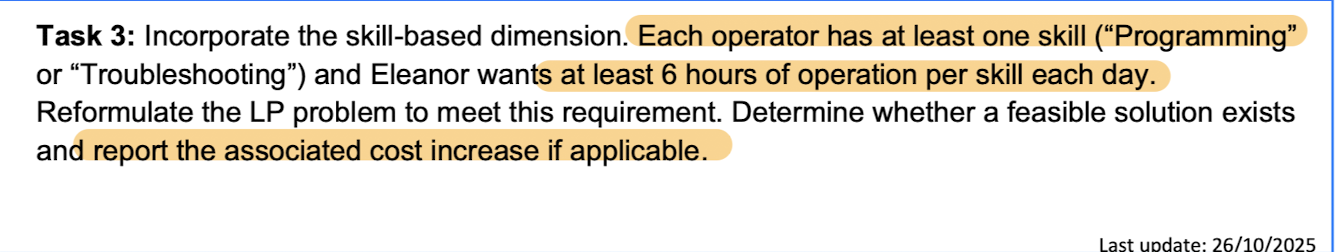

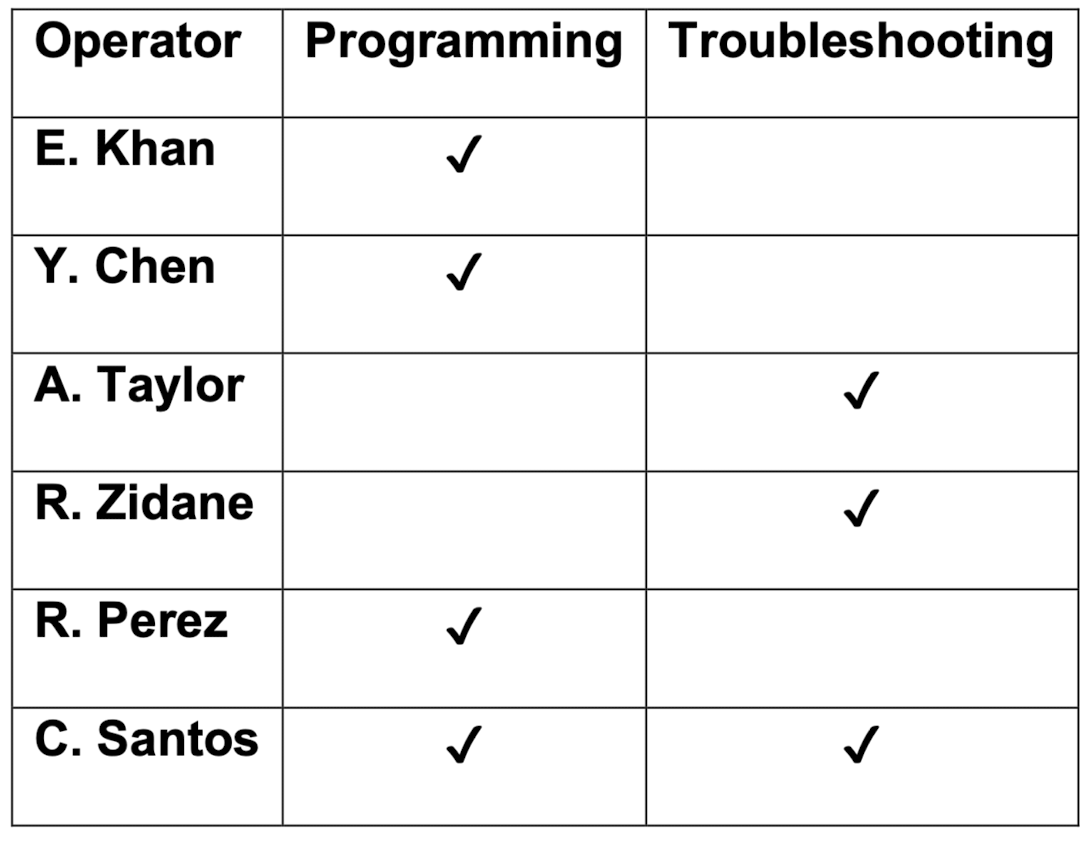

In [24]:
# REPLACE these with the correct sets from the coursework table
prog_ops = ["EK", "YC", "RP","CS"]  
trbl_ops = ["AT", "RZ"]      # example only

m3, x3, ops3, days3, wage3 = build_task3_model(prog_ops, trbl_ops)
m3.solve(pulp.PULP_CBC_CMD(msg=False))

task3_cost = pulp.value(m3.objective)
print("Task 3 cost:", task3_cost)

abs_increase = task3_cost - base_cost
perc_increase = abs_increase / base_cost * 100

print("Absolute increase:", abs_increase)
print("Percentage increase (%):", perc_increase)


Task 3 cost: 1754.0
Absolute increase: -1.0
Percentage increase (%): -0.056980056980056974
